# Task 3- CNN architecture

Neural networks require us to flatten the image into a 1D tensor, but while doing so we loose spatial context

To avoid that we make use of many layers such as Convolutional, Pooling,Dropout etc


THE Dataset
The total number of images in the dataset is 60000
Single image shape: torch.Size([1, 28, 28])
Associated target label: 2


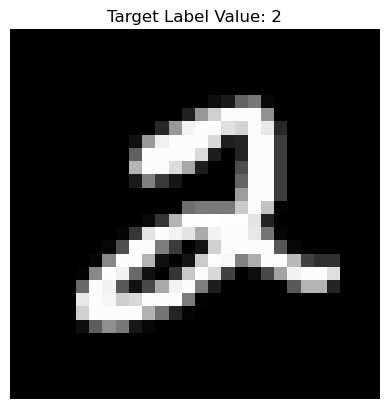

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])


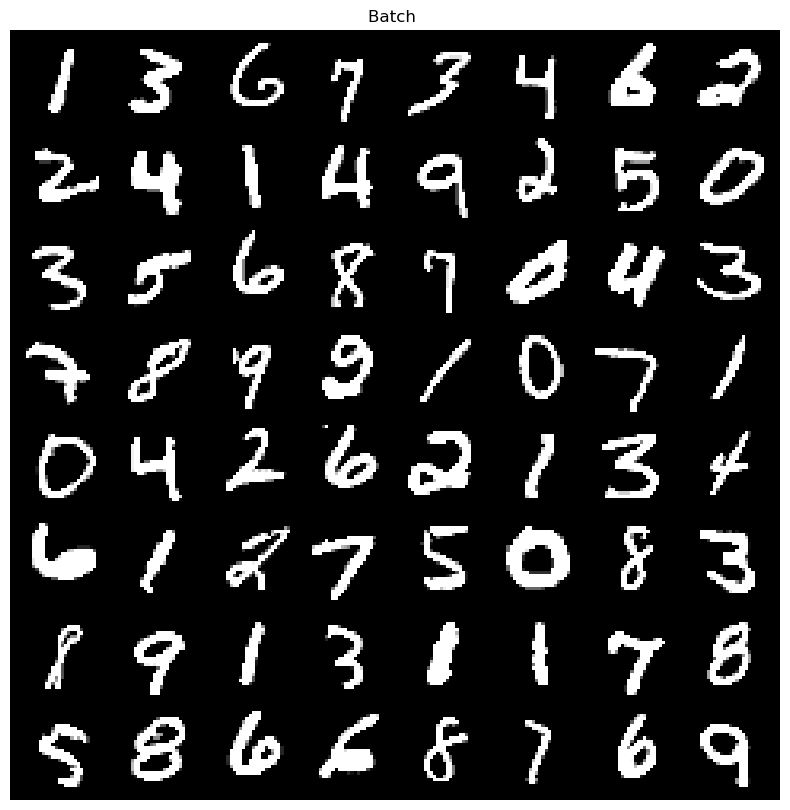

In [2]:
#copying task 2 code to move ahead
#Copying all the code from task 1 to move forward

import torch
import torchvision  #lib for computer vision in pytorch ecosystem
from torchvision.transforms import Compose, ToTensor, Normalize
import matplotlib.pyplot as plt 
#To transform the raw images (in png format) to tensors format we make us of the following:

transformy =Compose([
    ToTensor(), # it also scales the pixel values from [0,255] to [0,1] by dividing each value by 255
    
    #We normalize the pixel values further to center the data around 0 to help with the math.
    # The mean for the MNSIT dataset is 0.1307 and std dev is 0.3081 so we nromalize around these two using ((x-0.1307)/0.3081)
    Normalize((0.1307,),(0.3081,))
])

#downloading the dataset - both the training one and test one and applying transform on each image
train_dataset=torchvision.datasets.MNIST(
    root='./data',
    train = True,
    download=True,
    transform=transformy
)

test_dataset=torchvision.datasets.MNIST(
    root='./data',
    train= False,
    download=True,
    transform=transformy
)
print("THE Dataset")
print(f"The total number of images in the dataset is {len(train_dataset)}")
#The Mnsit dataset is in form of tuple pairs of the (image,itslabel integer)

single_image, single_label= train_dataset[5] #by changing the index we can access different images and look at their shapes 
print(f"Single image shape: {single_image.shape}")
print(f"Associated target label: {single_label}")
#Using matplotlib to render the images 
plt.imshow(single_image.squeeze(), cmap='gray') #squeeze changes the shape from [1,28,28] to [28,28] so that matplotlib can understand
plt.title(f"Target Label Value: {single_label}")
plt.axis('off')#disables the axes
plt.show()# final output
# A Dataloader is something that wraps an iterable about the dataset and helps in easier access to the data items.
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=64, shuffle=False)
#Batch size=64 meaning 64 similar images are grouped together into a batch , shuffling the training dataset is important so that it doesnt memorize the sequence.
# To iterate through the dataloader we convert it into a python iterator using iter(), next() grabs each batch 
image_batch, label_batch = next(iter(train_loader))
# features of the batch
print(f"Batch of images shape: {image_batch.shape}") #[batch size, channel, height, width]
print(f"Batch of labels shape: {label_batch.shape}")
#rendering a batch by making a grid in pytorch and then converting it to matplotlib's layout using .permute()
grid_tensor = torchvision.utils.make_grid(image_batch, nrow=8, padding=2)
grid_np = grid_tensor.permute(1, 2, 0).numpy()# by pytorch [C-0,H-1,W-2] --> by matplotlob [H,W,C] so(1,2,0)
plt.figure(figsize=(10, 10))
plt.imshow(grid_np)
plt.title("Batch ")
plt.axis('off')
plt.show()

In [3]:
import torch 
import torch.nn as nn       # nn.Module is the base class for every neural network and is used to manage, train and test.
import torch.nn.functional as F


In [4]:
class MNIST_CNN(nn.Module): # a class inheriting nn.Module class
        def __init__(self):
                super(MNIST_CNN, self).__init__() # super() is used to directly use the parent class

                # first convolutional block , 1 input channel (greyscale)- 32 output channels(32 filters)
                self.conv1=nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)

                # max pooling layer- shrinks the image size and also the number of calculations, (2x2) pooling layer gives the max value in a (2x2) neighbourhood
                self.pool= nn.MaxPool2d(kernel_size=2,stride=2) #reduces height and width by half

                #second convolution block, 32 input channels(feature maps from conv1), 64 output channels(more filters)
                self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

                #dropout layer- turns off a given percenrage of neurons. Done to counter overfitting.
                self.dropout = nn.Dropout(p=0.25) #switches off 25% of neurons

                #fully connected layers - to finally flatten the grid to 1D vector.
                #start- 28x28 -> conv1->28x28->pool->14x14->conv2->14x14
                #total flattened features :64channels*14h*14w
                self.fc1 = nn.Linear(in_features=64 * 14 * 14, out_features=128)

                #final output layer- 128 hidden features -> 10 output(digits 0-9)
                self.fc2 = nn.Linear(in_features=128, out_features=10)

        def forward(self, x):
                        # Pass through Conv1, activate with ReLU, and apply downsampling MaxPool
                        x = self.pool(F.relu(self.conv1(x)))  # [64, 1, 28, 28] -> [64, 32, 14, 14]
        
                        # Pass through Conv2 and activate with ReLU only (No pooling here)
                        x = F.relu(self.conv2(x))             # [64, 32, 14, 14] -> [64, 64, 14, 14]
        
                        # Flatten the multidimensional grid into a 1D vector per image batch sample
                        # -1 automatically retains our batch dimension size (64)
                        x = x.view(-1, 64 * 14 * 14)          # [64, 64, 14, 14] -> [64, 12544]
        
                        # Apply dropout to keep the network from memorizing pixel placements
                        x = self.dropout(x)
        
                        # Run through the dense hidden layer with ReLU activation
                        x = F.relu(self.fc1(x))               # [64, 12544] -> [64, 128]
        
                        # Final output layer to fetch raw class scores
                        x = self.fc2(x)                       # [64, 128] -> [64, 10]
        
                        return x


In [5]:
# 1. A physical instance of the neural network chassis
model = MNIST_CNN()
print("🎉 Model architecture successfully built without errors!")

# 2. Extracting a training batch
test_images, test_labels = next(iter(train_loader))

# 3. A mock test-drive pass through your forward function
output_logits = model(test_images)

print("\nStructural Diagnostics")
print(f"Input image batch tensor shape:  {test_images.shape}  -> [Batch, Channels, Height, Width]")
print(f"Output predicted logit tensor shape: {output_logits.shape}   -> [Batch, Target Classes]")

# Calculate total network weights/biases
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model trainable weights/parameters: {total_params:,}")

🎉 Model architecture successfully built without errors!

Structural Diagnostics
Input image batch tensor shape:  torch.Size([64, 1, 28, 28])  -> [Batch, Channels, Height, Width]
Output predicted logit tensor shape: torch.Size([64, 10])   -> [Batch, Target Classes]
Total model trainable weights/parameters: 1,625,866


---
# MNSIT Project 2 
## Modifying the notebook 
---
## Task 1 of Project 2 --- The training loop
 ### > weights(w) and biases(b)  ---> y=xW + b; x is brightness value of the pixel, weight is basically its importance 

In [6]:
import torch.optim as optim  # library for optimizing algorithms 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   #hardware
#sending my above MNSIT model to the device
model=MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss() #this function checks if the output value is correct or not
optimizer = optim.Adam(model.parameters(), lr=0.001)  #adjusts the weights using the Adam() algorithm with learning rate = 0.001

print(f"🚀 Training engine initialized on device: {device.type.upper()}")

def train(model, train_loader, criterion, optimizer, device):
    model.train() #turns on training mode majorly effectiong dropout layer 

    running_loss=0.0
    correct_predictions=0
    total_samples=0

    print("Starting training")
    # iterating through the batches
    for batch_id, (images, labels) in enumerate(train_loader):
        #sending the images and labels to the same hardware as the model
        images, labels=images.to(device), labels.to(device)

        #zero out the previous batch's gradient to start fresh with this batch
        optimizer.zero_grad()

        #forward pass through the batch 
        outputs= model(images)

        #calculating the loss (error) for the current batch
        loss = criterion(outputs, labels)

        #backpropagation
        loss.backward()
        #updating the weights by optimizer
        optimizer.step()

        #tracking the training statistics
        running_loss += loss.item() * images.size(0) #avg loss per image in the batch * no of imgs in the batch
        _, predicted = torch.max(outputs.data, 1) #max outputs two things - the raw score and the digit(index) we only want the digit which is stored in predicted
                                                    # (outputs.data, 1) is typed so that it compares the scores of the columns of a single row
                                                    #outputs has the structure as the following - columns is 0,1,2,3,4,5,6,7,8,9 each digit's score, a row is one image.

        total_samples+=labels.size(0) #no of imgs
        correct_predictions += (predicted == labels).sum().item()

        #Progress of the training at an interval of 200 batches
        if(batch_id+1)%200 ==0:
            current_loss = running_loss/total_samples
            current_accu=(correct_predictions/total_samples)*100
            print(f"Batch [{batch_id +1}/{len(train_loader)}] -> Running Loss: {current_loss:.4f} | Running Acc: {current_accu:.2f}%")
    
    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions / total_samples) * 100
    return epoch_loss, epoch_acc

avg_loss, avg_acc = train(model, train_loader, criterion, optimizer, device)
print(f"Final Epoch Loss: {avg_loss:.4f} | Final Epoch Accuracy: {avg_acc:.2f}%")


    

🚀 Training engine initialized on device: CPU
Starting training


Batch [200/938] -> Running Loss: 0.2982 | Running Acc: 90.53%
Batch [400/938] -> Running Loss: 0.2018 | Running Acc: 93.62%
Batch [600/938] -> Running Loss: 0.1582 | Running Acc: 94.99%
Batch [800/938] -> Running Loss: 0.1348 | Running Acc: 95.73%
Final Epoch Loss: 0.1242 | Final Epoch Accuracy: 96.08%


---
## Task 2 of Project 2 --> Evaluation


In [7]:
def test(model, test_loader, criterion, device):
    model.eval() #turns on testing mode (turns off dropout so that model works in 100% capacity)
    test_loss=0.0
    correct_predictions=0
    total_samples=0

    print("\n Start Model Evaluation ")

    with torch.no_grad(): #disables gradient calculation which was on in training mode 
        for images, labels in test_loader: #looping through the batches in test dataloader
            images, labels= images.to(device), labels.to(device) #moving to same device as model
            outputs = model(images) #forward pass (no backtracking needed)
            loss= criterion(outputs, labels) #calculating avg loss per image in batch

            test_loss+= loss.item() * images.size(0)
            _,predicted = torch.max(outputs.data, 1)
            total_samples+= labels.size(0)
            correct_predictions+=(predicted == labels).sum().item()

    final_loss = test_loss/total_samples
    final_accu = (correct_predictions/total_samples) *100
    
    return final_loss,final_accu

print ("Training another epoch")
train_loss, train_accu = train(model, train_loader, criterion, optimizer, device)
print(f"Training Result -> Loss:{train_loss:.4f} | Accuracy: {train_accu:.2f}%")

print("Running Evalution")
val_loss, val_accu = test(model, test_loader, criterion, device)

print("\n -------------")
print("Test Result")
print(f"Final Test Loss: {val_loss:.4f}")
print(f"Final Test Accuracy: {val_accu:.2f}%")





Training another epoch
Starting training
Batch [200/938] -> Running Loss: 0.0455 | Running Acc: 98.52%
Batch [400/938] -> Running Loss: 0.0440 | Running Acc: 98.54%
Batch [600/938] -> Running Loss: 0.0442 | Running Acc: 98.61%
Batch [800/938] -> Running Loss: 0.0434 | Running Acc: 98.63%
Training Result -> Loss:0.0433 | Accuracy: 98.64%
Running Evalution

 Start Model Evaluation 

 -------------
Test Result
Final Test Loss: 0.0385
Final Test Accuracy: 98.66%


---
# Task 3 of Project 2 - Save, Load and Reflect
### Difference between Full model saving and state dict saving
#### 1. Full Model --> (torch.save(model,path)) Saves the entire python class along with the weights. Breaks completely if moved to another directory or renamed.
#### 2. State Dict --> (torch.save(model.state_dict(),path)) Extracts only the parameters without binding itself to a specific directory.

 Model state dict saved succesfully to: 'mnsit_cnn_model.pt'
Model recreated, passed the weights, and turned on evaluation mode
   Inference Result -> Model Prediction: [7] | Real True Answer: [7]
Generating Final Performance Curve


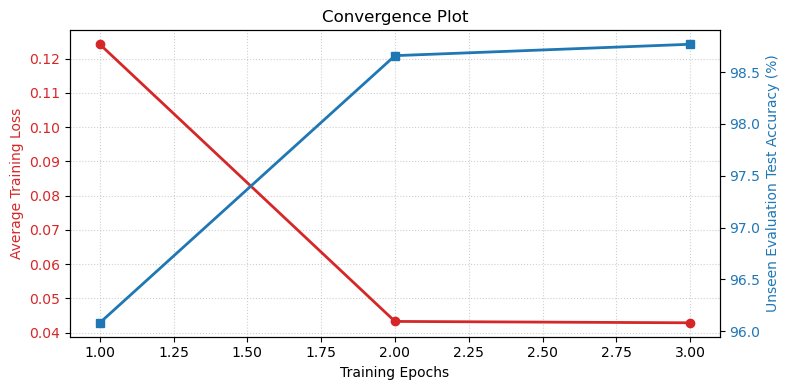

In [8]:
MODEL_SAVE_PATH = "mnsit_cnn_model.pt" #pytorch binary file that maps the layer name with their weight tensors (basically a dictionary)

torch.save(model.state_dict(), MODEL_SAVE_PATH) #saving to hard drive the weight tensor dictionary
print(f" Model state dict saved succesfully to: '{MODEL_SAVE_PATH}'")

# Creating a inexperienced structure of the architecture to which we will pass the .pt file
inference_model = MNIST_CNN()

#injecting the weight dictionary from the hard drive
inference_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=torch.device('cpu')))
inference_model.eval()
print("Model recreated, passed the weights, and turned on evaluation mode")

images, labels=next(iter(test_loader))
sample_image = images[0].unsqueeze(0) #unsqueeze adds a dimension so [1,28,28] turns to [1,1,28.28]
true_label=labels[0].item()

with torch.no_grad(): #not calculating gradients
    raw_output = inference_model(sample_image)
    _, predicted_digit = torch.max(raw_output, 1)

print(f"   Inference Result -> Model Prediction: [{predicted_digit.item()}] | Real True Answer: [{true_label}]")

#Plotting using matplotlib
print("Generating Final Performance Curve")

epochs_axis = [1, 2, 3]
real_train_losses = [0.1242, 0.0433, 0.0429]   # Extracted from terminal outputs
real_test_accuracies = [96.08, 98.66, 98.77]

fig, ax1 = plt.subplots(figsize=(8, 4))
# Setup Left Y-Axis for Loss Trend
color_loss = 'tab:red'
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Average Training Loss', color=color_loss)
ax1.plot(epochs_axis, real_train_losses, color=color_loss, marker='o', linewidth=2, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle=':', alpha=0.6)

# Setup Right Y-Axis for Accuracy Verification
ax2 = ax1.twinx()
color_acc = 'tab:blue'
ax2.set_ylabel('Unseen Evaluation Test Accuracy (%)', color=color_acc)
ax2.plot(epochs_axis, real_test_accuracies, color=color_acc, marker='s', linewidth=2, label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)

plt.title('Convergence Plot')
fig.tight_layout()
plt.show()
